# PPE Detection 시연 전용 노트북

| # | 시연 항목 | 섹션 |
|---|----------|------|
| 1 | YOLOv8n 기본 웹캠 | 섹션 2 |
| 2 | YOLOv10n 웹캠 | 섹션 3 |
| 3 | YOLOv8n + Pose 앙상블 웹캠 | 섹션 4 |
| 4 | YOLOv8n 평가 지표 | 섹션 5 |
| 5 | v8n vs v10n 비교 | 섹션 6 |
| 6 | 앙상블 평가 지표 | 섹션 7 |

**사용법**: 섹션 1(공통 설정)을 먼저 실행한 후, 필요한 섹션만 골라서 실행하세요.

---
## 1. 공통 설정 (반드시 먼저 실행)

In [2]:
!pip install ultralytics==8.3.40 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 898.5/898.5 kB 16.3 MB/s eta 0:00:00


In [3]:
import os, cv2, time, io, glob, yaml
import numpy as np
import PIL.Image
import torch
from ultralytics import YOLO
from collections import Counter
from IPython.display import display, Javascript, clear_output, Image as IPImage

print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
GPU: Tesla T4


In [4]:
# Google Drive 마운트 + 모델 로드
from google.colab import drive
drive.mount('/content/drive')

# ============================================
# 경로 설정 (본인 환경에 맞게 수정)
# ============================================
V8N_PATH  = '/content/drive/MyDrive/PPE_Model/best_260409.pt'   # YOLOv8n
V10N_PATH = '/content/drive/MyDrive/PPE_Model/best_v10n.pt'     # YOLOv10n
DATA_YAML = '/content/dataset/data.yaml'                         # 평가용 (섹션 5~7)

# 모델 로드
model_v8 = YOLO(V8N_PATH)
print(f"v8n 로드 완료: {model_v8.names}")

if os.path.exists(V10N_PATH):
    model_v10 = YOLO(V10N_PATH)
    print(f"v10n 로드 완료: {model_v10.names}")
else:
    model_v10 = None
    print(f"v10n 없음 → 섹션 3, 6 사용 불가")

model_pose = YOLO('yolov8n-pose.pt')
print(f"Pose 모델 로드 완료")

# 클래스 매핑 (자동)
CLASS_MAP = {}
for idx, name in model_v8.names.items():
    nl = name.lower()
    if 'person' in nl: CLASS_MAP[idx] = 'person'
    elif 'helmet' in nl or 'hardhat' in nl: CLASS_MAP[idx] = 'helmet'
    elif 'vest' in nl: CLASS_MAP[idx] = 'vest'
print(f"클래스 매핑: {CLASS_MAP}")

Mounted at /content/drive
v8n 로드 완료: {0: 'helmet', 1: 'person', 2: 'vest'}
v10n 로드 완료: {0: 'helmet', 1: 'person', 2: 'vest'}


100%|██████████| 6.52M/6.52M [00:00<00:00, 87.1MB/s]

Pose 모델 로드 완료
클래스 매핑: {0: 'helmet', 1: 'person', 2: 'vest'}


In [5]:
import os
import shutil

# 복사할 원본 파일과 드라이브의 대상 경로 설정
source_pose_path = 'yolov8n-pose.pt'
drive_pose_path = '/content/drive/MyDrive/PPE_Model/yolov8n-pose.pt'

# 파일이 존재하는지 확인 후 복사
if os.path.exists(source_pose_path):
    shutil.copy(source_pose_path, drive_pose_path)
    print(f"Pose 모델이 드라이브에 성공적으로 저장되었습니다: {drive_pose_path}")
else:
    print(f"{source_pose_path} 파일을 찾을 수 없습니다. 모델 로드 셀을 먼저 실행했는지 확인해주세요.")

Pose 모델이 드라이브에 성공적으로 저장되었습니다: /content/drive/MyDrive/PPE_Model/yolov8n-pose.pt


In [ ]:
# ============================================
# 공통 웹캠 함수
# ============================================
from google.colab.output import eval_js
from base64 import b64decode
from IPython.display import display, Javascript, Image as IPImage
import numpy as np
import cv2
import io
import PIL.Image

def setup_webcam():
    js = Javascript('''
        window.initCamera = async function() {
            const video = document.createElement('video');
            video.width = 640; video.height = 480;
            const stream = await navigator.mediaDevices.getUserMedia(
                {video: {width: 640, height: 480}});
            video.srcObject = stream;
            await video.play();
            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            window._video = video;
            window._canvas = canvas;
            return [video.videoWidth, video.videoHeight];
        };
        window.captureFrame = async function() {
            if (!window._canvas) return null;
            window._canvas.getContext('2d').drawImage(window._video, 0, 0);
            return window._canvas.toDataURL('image/jpeg', 0.8);
        };
        window.stopCamera = async function() {
            if (window._video && window._video.srcObject) {
                window._video.srcObject.getTracks().forEach(t => t.stop());
            }
        };
    ''')
    display(js)
    dims = eval_js('window.initCamera()')
    print(f"카메라 시작: {dims}")
    return dims

def grab_frame():
    data_url = eval_js('window.captureFrame()')
    if not data_url:
        return None
    binary = b64decode(data_url.split(',')[1])
    arr = np.frombuffer(binary, dtype=np.uint8)
    return cv2.imdecode(arr, cv2.IMREAD_COLOR)

def stop_webcam():
    eval_js('window.stopCamera()')
    print("카메라 종료")

# 전역 디스플레이 핸들 저장용 변수
_display_handle = None

def show_frame(frame, text_lines=None):
    global _display_handle
    if text_lines:
        for i, txt in enumerate(text_lines):
            cv2.putText(frame, txt, (10, 30 + i*35),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    buf = io.BytesIO()
    PIL.Image.fromarray(rgb).save(buf, format='JPEG', quality=80)
    img_obj = IPImage(data=buf.getvalue(), width=640)

    if _display_handle is None:
        _display_handle = display(img_obj, display_id=True)
    else:
        _display_handle.update(img_obj)

print("공통 함수 로드 완료")


공통 함수 로드 완료


In [ ]:
# ============================================
# 공통 앙상블 함수 (섹션 4, 7에서 사용)
# ============================================
HEAD_KP = [0, 1, 2, 3, 4]
SHOULDER_KP = [5, 6]
KP_THRESH = 0.3

def kp_center(kps, kc, indices):
    pts = [kps[i] for i in indices if kc[i] > KP_THRESH and kps[i][0] > 0]
    if not pts: return None
    pts = np.array(pts)
    return (float(np.mean(pts[:,0])), float(np.mean(pts[:,1])))

def iou(a, b):
    ix1, iy1 = max(a[0],b[0]), max(a[1],b[1])
    ix2, iy2 = min(a[2],b[2]), min(a[3],b[3])
    inter = max(0,ix2-ix1)*max(0,iy2-iy1)
    union = (a[2]-a[0])*(a[3]-a[1])+(b[2]-b[0])*(b[3]-b[1])-inter
    return inter/union if union>0 else 0

def judge_helmet(pbox, helmets, head_c):
    px1,py1,px2,py2 = pbox
    ph, pw = py2-py1, px2-px1
    inside = []
    for h in helmets:
        cx = (h[0]+h[2])/2; cy = (h[1]+h[3])/2
        if px1-pw*0.1<=cx<=px2+pw*0.1 and py1-ph*0.1<=cy<=py2+ph*0.1:
            inside.append(h)
    if not inside: return 'not_detected'
    for h in inside:
        hcx=(h[0]+h[2])/2; hcy=(h[1]+h[3])/2
        if head_c:
            dy = head_c[1]-hcy; dx = abs(head_c[0]-hcx)
            if dy > -ph*0.15 and dx < pw*0.4: return 'worn'
        else:
            if hcy < py1+ph*0.30: return 'worn'
    return 'carried'

def judge_vest(pbox, vests, shld_c):
    px1,py1,px2,py2 = pbox
    ph, pw = py2-py1, px2-px1
    inside = []
    for v in vests:
        cx=(v[0]+v[2])/2; cy=(v[1]+v[3])/2
        if px1-pw*0.1<=cx<=px2+pw*0.1 and py1-ph*0.1<=cy<=py2+ph*0.1:
            inside.append(v)
    if not inside: return 'not_detected'
    for v in inside:
        vcy=(v[1]+v[3])/2
        if shld_c:
            if abs(vcy-shld_c[1]) < ph*0.35: return 'worn'
        else:
            rel = (vcy-py1)/ph
            if 0.15<=rel<=0.70: return 'worn'
    return 'not_detected'

def run_ensemble(frame, det_model, pose_model, conf=0.4, use_pose=True):
    det = det_model.predict(frame, imgsz=640, conf=conf, iou=0.5, verbose=False)[0]
    persons, helmets, vests = [], [], []
    if det.boxes is not None:
        for box in det.boxes:
            cid = int(box.cls[0])
            if cid not in CLASS_MAP: continue
            b = box.xyxy[0].cpu().numpy().tolist()
            label = CLASS_MAP[cid]
            if label=='person': persons.append(b)
            elif label=='helmet': helmets.append(b)
            elif label=='vest': vests.append(b)

    pose_list = []
    if use_pose:
        pr = pose_model.predict(frame, imgsz=640, conf=0.4, verbose=False)[0]
        if pr.keypoints is not None and pr.boxes is not None:
            for i in range(len(pr.boxes)):
                pb = pr.boxes[i].xyxy[0].cpu().numpy().tolist()
                kp = pr.keypoints[i].data[0].cpu().numpy()
                pose_list.append((pb, kp[:,:2], kp[:,2]))

    results = []
    for p in persons:
        hc, sc, kps, kc_arr = None, None, None, None
        if pose_list:
            best_i, best_v = -1, 0
            for ki,(pb,kps_,kc_) in enumerate(pose_list):
                v = iou(p, pb)
                if v > best_v: best_v, best_i = v, ki
            if best_v > 0.5 and best_i >= 0:
                _,kps,kc_arr = pose_list[best_i]
                hc = kp_center(kps, kc_arr, HEAD_KP)
                sc = kp_center(kps, kc_arr, SHOULDER_KP)

        h_st = judge_helmet(p, helmets, hc)
        v_st = judge_vest(p, vests, sc)
        safe = (h_st=='worn' and v_st=='worn')
        results.append({'bbox':p,'helmet':h_st,'vest':v_st,'safe':safe,
                        'head_c':hc,'shoulder_c':sc,'kps':kps,'kc':kc_arr})
    return results

# 앙상블 시각화
C_SAFE=(0,200,0); C_WARN=(0,180,255); C_DANGER=(0,0,220)
SC = {'worn':C_SAFE,'carried':C_WARN,'not_detected':C_DANGER}

def draw_ensemble(frame, results, show_kp=True):
    out = frame.copy()
    vio = 0
    for r in results:
        x1,y1,x2,y2 = [int(v) for v in r['bbox']]
        color = C_SAFE if r['safe'] else (C_WARN if r['helmet']=='carried' else C_DANGER)
        if not r['safe']: vio += 1
        cv2.rectangle(out,(x1,y1),(x2,y2),color,2)
        cv2.rectangle(out,(x1,y1-48),(x1+200,y1),(30,30,30),-1)
        cv2.putText(out,f"H:{r['helmet']}",(x1+4,y1-28),cv2.FONT_HERSHEY_SIMPLEX,0.5,SC[r['helmet']],1)
        cv2.putText(out,f"V:{r['vest']}",(x1+4,y1-8),cv2.FONT_HERSHEY_SIMPLEX,0.5,SC[r['vest']],1)
        ptag = 'P' if r['head_c'] else '-'
        cv2.putText(out,f"[{ptag}]",(x1+160,y1-18),cv2.FONT_HERSHEY_SIMPLEX,0.4,(180,180,180),1)
        if show_kp and r['kps'] is not None and r['kc'] is not None:
            for i in HEAD_KP:
                if r['kc'][i]>KP_THRESH:
                    cv2.circle(out,(int(r['kps'][i][0]),int(r['kps'][i][1])),4,(255,0,255),-1)
            for i in SHOULDER_KP:
                if r['kc'][i]>KP_THRESH:
                    cv2.circle(out,(int(r['kps'][i][0]),int(r['kps'][i][1])),4,(255,255,0),-1)
            if r['head_c']:
                cv2.drawMarker(out,(int(r['head_c'][0]),int(r['head_c'][1])),(0,255,255),cv2.MARKER_CROSS,12,2)
    return out, vio

print("앙상블 함수 로드 완료")

앙상블 함수 로드 완료


---
## 2. 시연 1 — YOLOv8n 기본 웹캠

In [ ]:
setup_webcam()

<IPython.core.display.Javascript object>

카메라 시작: [640, 480]


[640, 480]

<IPython.core.display.Javascript object>

카메라 시작: [640, 480]


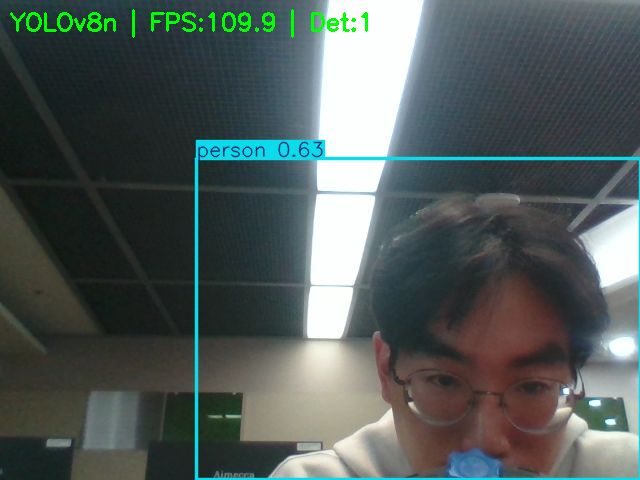


중단
카메라 종료


In [ ]:
# YOLOv8n Detection only 실시간
# 중지: Ctrl+M+I
setup_webcam()  # 콜랩 환경에서는 동일 셀에서 JS를 주입해야 합니다.

N = 300
_display_handle = None # 디스플레이 핸들 초기화
try:
    for i in range(N):
        frame = grab_frame()
        if frame is None: continue
        t0 = time.time()
        res = model_v8.predict(frame, imgsz=640, conf=0.4, verbose=False)
        fps = 1.0/(time.time()-t0)
        vis = res[0].plot()
        n_det = len(res[0].boxes) if res[0].boxes is not None else 0
        show_frame(vis, [f"YOLOv8n | FPS:{fps:.1f} | Det:{n_det}"])
        print(f"Frame {i+1}/{N}", end="\r") # 줄바꿈 대신 덮어쓰기
except KeyboardInterrupt:
    print("\n중단")
finally:
    stop_webcam()


---
## 3. 시연 2 — YOLOv10n 웹캠

In [ ]:
assert model_v10 is not None, "v10n 모델이 로드되지 않았습니다. V10N_PATH를 확인하세요."
setup_webcam()

<IPython.core.display.Javascript object>

카메라 시작: [640, 480]


[640, 480]

<IPython.core.display.Javascript object>

카메라 시작: [640, 480]


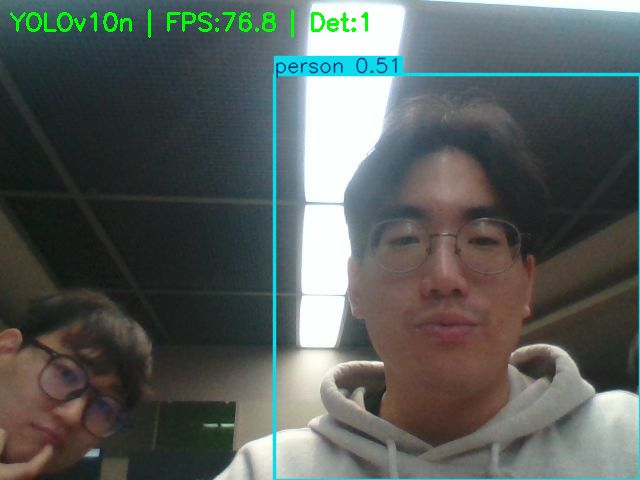

Frame 139/300
중단


KeyboardInterrupt: 

In [ ]:
# YOLOv10n Detection only 실시간
setup_webcam()  # 콜랩 환경에서는 동일 셀에서 JS를 주입해야 합니다.

N = 300
_display_handle = None # 디스플레이 핸들 초기화
try:
    for i in range(N):
        frame = grab_frame()
        if frame is None: continue
        t0 = time.time()
        res = model_v10.predict(frame, imgsz=640, conf=0.4, verbose=False)
        fps = 1.0/(time.time()-t0)
        vis = res[0].plot()
        n_det = len(res[0].boxes) if res[0].boxes is not None else 0
        show_frame(vis, [f"YOLOv10n | FPS:{fps:.1f} | Det:{n_det}"])
        print(f"Frame {i+1}/{N}", end="\r")
except KeyboardInterrupt:
    print("\n중단")
finally:
    stop_webcam()


---
## 4. 시연 3 — YOLOv8n + Pose 앙상블 웹캠

In [ ]:
setup_webcam()

<IPython.core.display.Javascript object>

카메라 시작: [640, 480]


[640, 480]

<IPython.core.display.Javascript object>

카메라 시작: [640, 480]


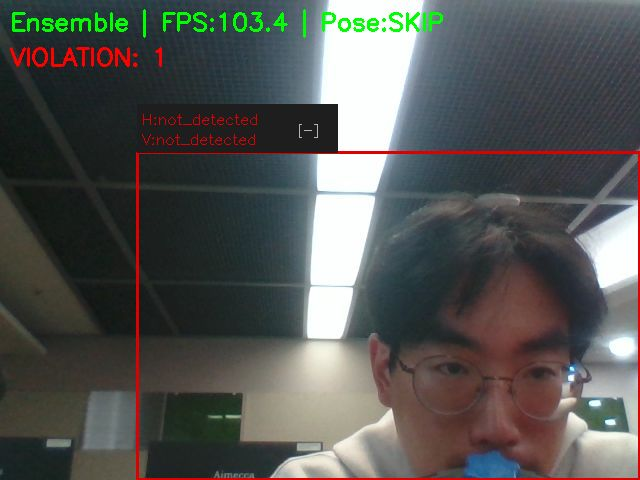

Frame 10/300 | Persons:1 | Safe:0 | Vio:1
중단
카메라 종료


In [ ]:
# 앙상블 실시간 (Pose 3프레임마다)
setup_webcam()

N = 300
POSE_EVERY = 3
fc = 0
_display_handle = None

try:
    for i in range(N):
        frame = grab_frame()
        if frame is None: continue
        fc += 1
        use_p = (fc % POSE_EVERY == 0)

        t0 = time.time()
        results = run_ensemble(frame, model_v8, model_pose, use_pose=use_p)
        fps = 1.0/(time.time()-t0)

        vis, vio = draw_ensemble(frame, results)
        pose_tag = "ON" if use_p else "SKIP"
        lines = [f"Ensemble | FPS:{fps:.1f} | Pose:{pose_tag}"]
        if vio > 0:
            cv2.putText(vis, f"VIOLATION: {vio}", (10, 65),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,0,255), 2)
        show_frame(vis, lines)

        safe_n = sum(1 for r in results if r['safe'])
        print(f"Frame {fc}/{N} | Persons:{len(results)} | Safe:{safe_n} | Vio:{vio}", end="\r")

except KeyboardInterrupt:
    print("\n중단")
finally:
    stop_webcam()


---
## 5. 평가 1 — YOLOv8n 평가 지표

In [ ]:
# 데이터셋 업로드 (평가용, 아직 안 올렸으면)
if not os.path.exists(DATA_YAML):
    from google.colab import files as gfiles
    print("데이터셋 zip을 업로드하세요")
    up = gfiles.upload()
    zn = list(up.keys())[0]
    !mkdir -p /content/dataset
    !unzip -q -o "{zn}" -d /content/dataset

    # data.yaml path 수정
    with open(DATA_YAML, 'r') as f:
        dc = yaml.safe_load(f)
    dc['path'] = '/content/dataset'
    with open(DATA_YAML, 'w') as f:
        yaml.dump(dc, f, default_flow_style=False)
    print("데이터셋 준비 완료")
else:
    print(f"데이터셋 존재: {DATA_YAML}")

데이터셋 zip을 업로드하세요


In [ ]:
# YOLOv8n 평가
m8 = model_v8.val(data=DATA_YAML, imgsz=640, batch=16)

print("\n" + "="*55)
print(" YOLOv8n 평가 결과")
print("="*55)
print(f" mAP@50     : {m8.box.map50:.4f}")
print(f" mAP@50-95  : {m8.box.map:.4f}")
print(f" Precision  : {m8.box.mp:.4f}")
print(f" Recall     : {m8.box.mr:.4f}")
print(f"\n 클래스별 AP@50:")
for i, ap in enumerate(m8.box.ap50):
    print(f"   {model_v8.names[i]:10s}: {ap:.4f}")

In [ ]:
# 추론 속도 측정
dummy = np.random.randint(0,255,(480,640,3),dtype=np.uint8)
for _ in range(10): model_v8.predict(dummy, imgsz=640, verbose=False)

t0 = time.time()
for _ in range(100): model_v8.predict(dummy, imgsz=640, verbose=False)
fps_v8 = 100/(time.time()-t0)

v8_size = os.path.getsize(V8N_PATH)/(1024*1024)

print(f"\n 추론 속도  : {fps_v8:.1f} FPS (T4 GPU)")
print(f" 모델 크기  : {v8_size:.1f} MB")
print(f" 파라미터   : ~3.2M")

---
## 6. 평가 2 — YOLOv8n vs YOLOv10n 비교

In [ ]:
import pandas as pd
assert model_v10 is not None, "v10n 모델 없음"

# 양쪽 평가
m8 = model_v8.val(data=DATA_YAML, imgsz=640, batch=16, verbose=False)
m10 = model_v10.val(data=DATA_YAML, imgsz=640, batch=16, verbose=False)

# FPS 측정
dummy = np.random.randint(0,255,(480,640,3),dtype=np.uint8)
for _ in range(10):
    model_v8.predict(dummy, imgsz=640, verbose=False)
    model_v10.predict(dummy, imgsz=640, verbose=False)

t0=time.time()
for _ in range(100): model_v8.predict(dummy, imgsz=640, verbose=False)
fps8 = 100/(time.time()-t0)

t0=time.time()
for _ in range(100): model_v10.predict(dummy, imgsz=640, verbose=False)
fps10 = 100/(time.time()-t0)

s8 = os.path.getsize(V8N_PATH)/(1024*1024)
s10 = os.path.getsize(V10N_PATH)/(1024*1024)

In [ ]:
# 비교표 출력
cls_names = [model_v8.names[i] for i in range(len(model_v8.names))]

rows = [
    ['mAP@50',     m8.box.map50, m10.box.map50],
    ['mAP@50-95',  m8.box.map,   m10.box.map],
    ['Precision',  m8.box.mp,    m10.box.mp],
    ['Recall',     m8.box.mr,    m10.box.mr],
]
for i, c in enumerate(cls_names):
    rows.append([f'AP@50 ({c})', m8.box.ap50[i], m10.box.ap50[i]])
rows.append(['FPS (T4)', fps8, fps10])
rows.append(['Size (MB)', s8, s10])

df = pd.DataFrame(rows, columns=['Metric', 'YOLOv8n', 'YOLOv10n'])
df['Diff'] = df.apply(lambda r: f"{r['YOLOv10n']-r['YOLOv8n']:+.4f}"
                      if isinstance(r['YOLOv8n'], float) else '', axis=1)
df['YOLOv8n'] = df['YOLOv8n'].apply(lambda x: f"{x:.4f}" if isinstance(x,float) and x<10 else f"{x:.1f}")
df['YOLOv10n'] = df['YOLOv10n'].apply(lambda x: f"{x:.4f}" if isinstance(x,float) and x<10 else f"{x:.1f}")

print("\n" + "="*65)
print(" YOLOv8n vs YOLOv10n 비교")
print("="*65)
print(df.to_string(index=False))
print("\n※ 동일 데이터셋, 동일 하이퍼파라미터, 동일 GPU")

---
## 7. 평가 3 — 앙상블 모델 평가 지표

In [ ]:
# ============================================
# 앙상블 평가: 테스트 이미지에서 Pose ON/OFF 비교
# Detection mAP는 모델 자체 성능이므로 동일.
# 앙상블의 가치는 "착용 판정 정확도"에 있음.
# ============================================

# 테스트 이미지 준비
os.makedirs('/content/test_images', exist_ok=True)
if len(glob.glob('/content/test_images/*.jpg')) == 0:
    !wget -q -O /content/test_images/s1.jpg \
        "https://github.com/snehilsanyal/Construction-Site-Safety-PPE-Detection/raw/main/source_files/construction-safety.jpg"
    !wget -q -O /content/test_images/s2.jpg \
        "https://github.com/snehilsanyal/Construction-Site-Safety-PPE-Detection/raw/main/source_files/two-young-construction-workers-wearing-555864.jpg"
    print("샘플 다운로드 완료 (직접 이미지 업로드도 가능)")

In [ ]:
# 앙상블 FPS 벤치마크 (3가지 모드)
dummy = np.random.randint(0,255,(480,640,3),dtype=np.uint8)
for _ in range(5): run_ensemble(dummy, model_v8, model_pose, use_pose=True)

N = 50

t0=time.time()
for _ in range(N): run_ensemble(dummy, model_v8, model_pose, use_pose=False)
fps_det = N/(time.time()-t0)

t0=time.time()
for _ in range(N): run_ensemble(dummy, model_v8, model_pose, use_pose=True)
fps_both = N/(time.time()-t0)

t0=time.time()
for i in range(N): run_ensemble(dummy, model_v8, model_pose, use_pose=(i%3==0))
fps_skip = N/(time.time()-t0)

print("\n" + "="*55)
print(" 앙상블 속도 벤치마크 (T4 GPU)")
print("="*55)
print(f" Detection only             : {fps_det:.1f} FPS")
print(f" Detection + Pose (every)   : {fps_both:.1f} FPS  ({(1-fps_both/fps_det)*100:.0f}% drop)")
print(f" Detection + Pose (skip 3)  : {fps_skip:.1f} FPS  ({(1-fps_skip/fps_det)*100:.0f}% drop)")
print(f"\n → skip 방식 FPS 회복률: {fps_skip/fps_det*100:.0f}%")

In [ ]:
# Pose ON vs OFF 시각적 비교 (이미지별)
for img_name in sorted(os.listdir('/content/test_images')):
    if not img_name.lower().endswith(('.jpg','.jpeg','.png')): continue
    frame = cv2.imread(f'/content/test_images/{img_name}')
    if frame is None: continue

    print(f"\n{'='*60}")
    print(f" {img_name} — Pose ON vs OFF")

    r_off = run_ensemble(frame, model_v8, model_pose, use_pose=False)
    r_on  = run_ensemble(frame, model_v8, model_pose, use_pose=True)

    v_off, _ = draw_ensemble(frame, r_off, show_kp=False)
    v_on,  _ = draw_ensemble(frame, r_on,  show_kp=True)

    cv2.putText(v_off,"Pose OFF",(10,30),cv2.FONT_HERSHEY_SIMPLEX,0.8,(255,255,255),2)
    cv2.putText(v_on, "Pose ON", (10,30),cv2.FONT_HERSHEY_SIMPLEX,0.8,(255,255,255),2)

    h = max(v_off.shape[0], v_on.shape[0])
    if v_off.shape[0]<h: v_off = cv2.copyMakeBorder(v_off,0,h-v_off.shape[0],0,0,cv2.BORDER_CONSTANT)
    if v_on.shape[0]<h:  v_on  = cv2.copyMakeBorder(v_on, 0,h-v_on.shape[0], 0,0,cv2.BORDER_CONSTANT)

    combined = np.hstack([v_off, v_on])
    pil = PIL.Image.fromarray(cv2.cvtColor(combined, cv2.COLOR_BGR2RGB))
    if pil.width > 1200:
        r = 1200/pil.width
        pil = pil.resize((1200, int(pil.height*r)))
    display(pil)

    # 판정 비교
    print(f"  {'':5s} {'Pose OFF':>20s} {'Pose ON':>20s}")
    for j in range(max(len(r_off), len(r_on))):
        off_h = r_off[j]['helmet'] if j<len(r_off) else '-'
        off_v = r_off[j]['vest']   if j<len(r_off) else '-'
        on_h  = r_on[j]['helmet']  if j<len(r_on) else '-'
        on_v  = r_on[j]['vest']    if j<len(r_on) else '-'
        diff = ' *' if (off_h!=on_h or off_v!=on_v) else ''
        print(f"  #{j+1:2d}  H:{off_h:14s} V:{off_v:14s}  |  H:{on_h:14s} V:{on_v:14s}{diff}")

In [ ]:
# 종합 요약
print("\n" + "="*60)
print(" 종합 평가 요약")
print("="*60)
print(f"\n [Detection 성능 (YOLOv8n)]")
print(f"   mAP@50: {m8.box.map50:.4f} | Precision: {m8.box.mp:.4f} | Recall: {m8.box.mr:.4f}")
print(f"\n [앙상블 속도]")
print(f"   Det only: {fps_det:.1f} FPS")
print(f"   Det+Pose (every): {fps_both:.1f} FPS ({(1-fps_both/fps_det)*100:.0f}% drop)")
print(f"   Det+Pose (skip3): {fps_skip:.1f} FPS ({(1-fps_skip/fps_det)*100:.0f}% drop)")
print(f"\n [차별점]")
print(f"   Pose keypoint 기반 착용/휴대/미착용 구분")
print(f"   적응형 Pose 추론으로 FPS {fps_skip/fps_det*100:.0f}% 유지")
print(f"\n [한계점]")
print(f"   - 밀집 환경에서 person-equipment 오매칭 가능")
print(f"   - 착탈 과도기 상태 판별 한계")
print(f"   - 손에 든 헬멧 detection 데이터 부족")

---
## 8. 사진(정적 이미지) 추론 테스트

추론할 이미지를 업로드해주세요:


Saving jv11352076.jpg to jv11352076.jpg
[jv11352076.jpg] 이미지에 대한 YOLOv8n 베이스 모델 추론 시작...


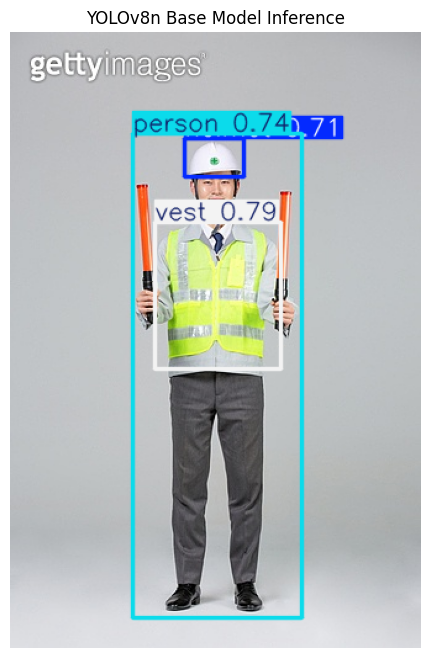

In [ ]:
# 1. YOLOv8n 베이스 모델 사진 추론
import cv2
import matplotlib.pyplot as plt
from google.colab import files
import os

print("추론할 이미지를 업로드해주세요:")
uploaded = files.upload()

if uploaded:
    # 업로드된 첫 번째 파일 이름 가져오기
    img_name = list(uploaded.keys())[0]
    img_path = f'/content/{img_name}'

    img = cv2.imread(img_path)

    if img is not None:
        print(f"[{img_name}] 이미지에 대한 YOLOv8n 베이스 모델 추론 시작...")
        # 모델 추론
        res = model_v8.predict(img_path, imgsz=640, conf=0.4, verbose=False)
        vis = res[0].plot()

        # 결과 출력
        plt.figure(figsize=(10, 8))
        plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title('YOLOv8n Base Model Inference')
        plt.show()
    else:
        print("이미지를 읽을 수 없습니다.")
else:
    print("업로드된 이미지가 없습니다.")

[/content/jv11352076.jpg] 이미지에 대한 앙상블 모델(Pose 적용) 추론 시작...


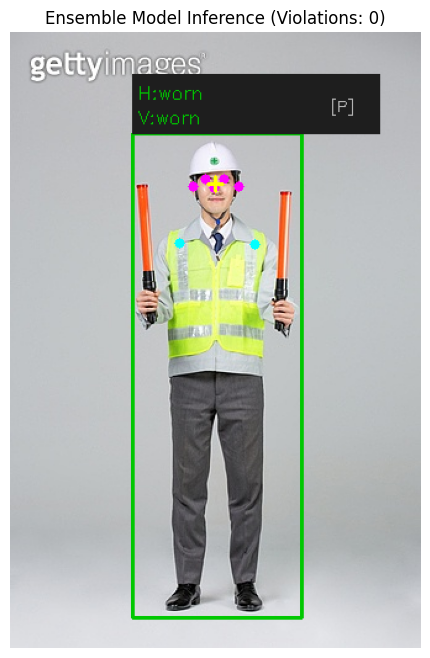

감지된 사람 수: 1 | 안전모/조끼 미착용 위반: 0


In [ ]:
# 2. 앙상블 모델(YOLOv8n + Pose) 사진 추론
if img is not None:
    print(f"[{img_path}] 이미지에 대한 앙상블 모델(Pose 적용) 추론 시작...")

    # 앙상블 함수 실행
    results = run_ensemble(img, model_v8, model_pose, use_pose=True)
    vis_ensemble, vio = draw_ensemble(img, results, show_kp=True)

    # 결과 출력
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(vis_ensemble, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f'Ensemble Model Inference (Violations: {vio})')
    plt.show()

    print(f"감지된 사람 수: {len(results)} | 안전모/조끼 미착용 위반: {vio}")

Pose 모델 단독 추론 시작...


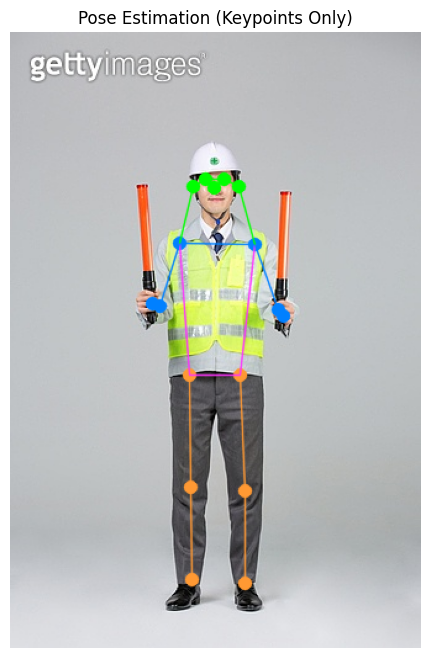

In [ ]:
# 3. Pose(키포인트) 단독 사진 추론 (발표 자료용)
if 'img' in locals() and img is not None:
    print("Pose 모델 단독 추론 시작...")

    # Pose 모델 추론
    res_pose = model_pose.predict(img, imgsz=640, conf=0.4, verbose=False)

    # boxes=False 옵션을 통해 바운딩 박스 없이 골격/키포인트만 시각화합니다.
    vis_pose = res_pose[0].plot(boxes=False)

    # 결과 출력
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(vis_pose, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('Pose Estimation (Keypoints Only)')
    plt.show()
else:
    print("먼저 위 셀에서 이미지를 업로드해주세요.")